# ObjChange-MambaDiff Full Experiment Notebook

Full runnable experiment notebook for the local satellite change-detection datasets under:

`D:\Datasets\Satillate`

The notebook performs dataset discovery, unified paired loading, xView2 JSON-to-mask conversion, Siamese U-Net baseline training, ObjChange-MambaDiff-Lite training, label-efficiency testing, cross-dataset testing, ablation testing, metric export, checkpoint export, and qualitative prediction export.

In [1]:
# ============================================================
# 0. Imports and environment check
# ============================================================
# Required packages:
# pip install torch torchvision pillow numpy pandas matplotlib tqdm scikit-learn opencv-python

import os, sys, json, time, random, math, warnings, hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

try:
    import cv2
    HAS_CV2=True
except Exception:
    HAS_CV2=False

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.9.18 (main, Sep 11 2023, 14:09:26) [MSC v.1916 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4060


In [2]:
# ============================================================
# 1. Configuration
# ============================================================

@dataclass
class CFG:
    ROOT: str = r"D:\Datasets\Satillate"
    PROJECT_NAME: str = "_objchange_mambadiff_full_experiment"
    SELECTED_DATASETS: tuple = ("LEVIR-CD", "S2Looking", "DSIFN-CD", "SECOND", "xView2")
    IMAGE_SIZE: int = 256
    BATCH_SIZE: int = 4
    NUM_WORKERS: int = 0
    EPOCHS: int = 50
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    AMP: bool = True
    SEED: int = 42
    MAX_TRAIN_SAMPLES: object = None
    MAX_VAL_SAMPLES: object = None
    MAX_TEST_SAMPLES: object = None
    RUN_MAIN_BENCHMARK: bool = True
    RUN_LABEL_EFFICIENCY: bool = True
    RUN_CROSS_DATASET: bool = True
    RUN_ABLATION: bool = True
    LABEL_FRACTIONS: tuple = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
    LABEL_EFF_EPOCHS: int = 25
    CROSS_EPOCHS: int = 25
    MAIN_MODELS: tuple = ("SiameseUNet", "ObjChangeMambaDiffLite")
    CHANGE_THRESHOLD: float = 0.5
    POS_WEIGHT_CLAMP: float = 10.0
    QUALITATIVE_N: int = 8

cfg = CFG()
ROOT = Path(cfg.ROOT)
OUT_DIR = ROOT / cfg.PROJECT_NAME
for sub in ["reports", "checkpoints", "figures", "qualitative_predictions", "cache_masks", "logs"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT, "exists=", ROOT.exists())
print("OUT_DIR:", OUT_DIR)
print("DEVICE:", device)
print(json.dumps(asdict(cfg), indent=2, default=str))

ROOT: D:\Datasets\Satillate exists= True
OUT_DIR: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment
DEVICE: cuda
{
  "ROOT": "D:\\Datasets\\Satillate",
  "PROJECT_NAME": "_objchange_mambadiff_full_experiment",
  "SELECTED_DATASETS": [
    "LEVIR-CD",
    "S2Looking",
    "DSIFN-CD",
    "SECOND",
    "xView2"
  ],
  "IMAGE_SIZE": 256,
  "BATCH_SIZE": 4,
  "NUM_WORKERS": 0,
  "EPOCHS": 50,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0001,
  "AMP": true,
  "SEED": 42,
  "MAX_TRAIN_SAMPLES": null,
  "MAX_VAL_SAMPLES": null,
  "MAX_TEST_SAMPLES": null,
  "RUN_MAIN_BENCHMARK": true,
  "RUN_LABEL_EFFICIENCY": true,
  "RUN_CROSS_DATASET": true,
  "RUN_ABLATION": true,
  "LABEL_FRACTIONS": [
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    1.0
  ],
  "LABEL_EFF_EPOCHS": 25,
  "CROSS_EPOCHS": 25,
  "MAIN_MODELS": [
    "SiameseUNet",
    "ObjChangeMambaDiffLite"
  ],
  "CHANGE_THRESHOLD": 0.5,
  "POS_WEIGHT_CLAMP": 10.0,
  "QUALITATIVE_N": 8
}


In [3]:
# ============================================================
# 2. Dataset discovery and pairing
# ============================================================

IMG_EXTS={".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}
JSON_EXTS={".json"}
DATASET_ALIASES={
    "LEVIR-CD":["levir", "levircd", "levir-cd", "levir cd"],
    "WHU-CD":["whu", "whucd", "whu-cd", "buildingchange"],
    "DSIFN-CD":["dsifn", "dsifncd", "dsifn-cd"],
    "CDD":["cdd", "changedetectiondataset", "change detection dataset"],
    "SECOND":["second"],
    "HRSCD":["hrscd"],
    "xView2":["xview2", "xbd", "xview"],
    "S2Looking":["s2looking", "s2 looking"]
}

def norm_name(s):
    return str(s).lower().replace(" ","").replace("-","").replace("_","")

def list_files(root, exts=None):
    root=Path(root)
    if not root.exists(): return []
    out=[]
    for p in root.rglob("*"):
        if p.is_file() and (exts is None or p.suffix.lower() in exts):
            out.append(p)
    return out

def infer_split(path):
    parts=[norm_name(x) for x in Path(path).parts]
    if any(x in ["train","training","trainset"] for x in parts): return "train"
    if any(x in ["val","valid","validation","valset"] for x in parts): return "val"
    if any(x in ["test","testing","testset"] for x in parts): return "test"
    return "unknown"

def common_stem(p):
    s=Path(p).stem
    for token in ["_pre_disaster","_post_disaster","_pre","_post","_A","_B","_label","_mask","_change"]:
        s=s.replace(token,"")
    return s

def find_dataset_roots(root):
    root=Path(root)
    candidates=[]
    search_dirs=[]
    if root.exists():
        search_dirs.append(root)
        search_dirs += [p for p in root.iterdir() if p.is_dir()]
        search_dirs += [p for p in root.glob("*/*") if p.is_dir()]
    for p in search_dirs:
        low=norm_name(p.name)
        for ds, aliases in DATASET_ALIASES.items():
            if any(norm_name(a) in low for a in aliases):
                candidates.append({"dataset":ds,"path":p,"reason":"name_match"})
    seen=set(); out=[]
    for c in candidates:
        key=(c["dataset"], str(c["path"]).lower())
        if key not in seen:
            out.append(c); seen.add(key)
    return out

def detect_role_folders(ds_root):
    roles={"A":[],"B":[],"MASK":[],"SEM1":[],"SEM2":[]}
    for f in Path(ds_root).rglob("*"):
        if not f.is_dir(): continue
        n=norm_name(f.name); text=norm_name(str(f.relative_to(ds_root)))
        if n in ["a","t1","time1","img1","image1","im1","before","pre","predisaster"] or "image1" in text or "time1" in text:
            roles["A"].append(f)
        if n in ["b","t2","time2","img2","image2","im2","after","post","postdisaster"] or "image2" in text or "time2" in text:
            roles["B"].append(f)
        if any(h in n for h in ["label","mask","gt","change"]):
            if any(x in n for x in ["2006","2012","landcover","land_cover"]):
                if "2006" in n or "t1" in n or "time1" in n: roles["SEM1"].append(f)
                if "2012" in n or "t2" in n or "time2" in n: roles["SEM2"].append(f)
            else:
                roles["MASK"].append(f)
    return roles

def pair_from_role_folders(dataset, ds_root):
    roles=detect_role_folders(ds_root)
    records=[]
    # binary pair A/B/mask
    for af in roles["A"]:
        split=infer_split(af)
        b_cands=sorted(roles["B"], key=lambda x:(infer_split(x)!=split, len(str(x))))
        m_cands=sorted(roles["MASK"], key=lambda x:(infer_split(x)!=split, len(str(x))))
        if not b_cands: continue
        bf=b_cands[0]
        mf=m_cands[0] if m_cands else None
        A={common_stem(p):p for p in list_files(af, IMG_EXTS)}
        B={common_stem(p):p for p in list_files(bf, IMG_EXTS)}
        M={common_stem(p):p for p in list_files(mf, IMG_EXTS)} if mf else {}
        for st in sorted(set(A)&set(B)):
            if st in M:
                records.append({"dataset":dataset,"split":split if split!="unknown" else infer_split(A[st]),"image_t1":A[st],"image_t2":B[st],"mask":M[st],"sem_t1":None,"sem_t2":None,"json":None,"source_root":ds_root})
    # semantic pair, convert semantic map difference to binary change
    if roles["SEM1"] and roles["SEM2"] and roles["A"] and roles["B"]:
        for af in roles["A"][:3]:
            split=infer_split(af)
            bf=sorted(roles["B"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            s1f=sorted(roles["SEM1"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            s2f=sorted(roles["SEM2"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            A={common_stem(p):p for p in list_files(af, IMG_EXTS)}
            B={common_stem(p):p for p in list_files(bf, IMG_EXTS)}
            S1={common_stem(p):p for p in list_files(s1f, IMG_EXTS)}
            S2={common_stem(p):p for p in list_files(s2f, IMG_EXTS)}
            for st in sorted(set(A)&set(B)&set(S1)&set(S2)):
                records.append({"dataset":dataset,"split":split,"image_t1":A[st],"image_t2":B[st],"mask":None,"sem_t1":S1[st],"sem_t2":S2[st],"json":None,"source_root":ds_root})
    return records

def pair_xview2(dataset, ds_root):
    files=list_files(ds_root, IMG_EXTS)
    pre={}; post={}
    for p in files:
        name=p.name.lower(); st=common_stem(p)
        if "pre_disaster" in name or "_pre_" in name or name.endswith("_pre.png"):
            pre[st]=p
        if "post_disaster" in name or "_post_" in name or name.endswith("_post.png"):
            post[st]=p
    jsons={common_stem(p):p for p in list_files(ds_root, JSON_EXTS)}
    recs=[]
    for st in sorted(set(pre)&set(post)):
        j=jsons.get(st) or jsons.get(st+"_post_disaster") or jsons.get(st+"_pre_disaster")
        recs.append({"dataset":dataset,"split":infer_split(pre[st]),"image_t1":pre[st],"image_t2":post[st],"mask":None,"sem_t1":None,"sem_t2":None,"json":j,"source_root":ds_root})
    return recs

def build_dataset_records(dataset, ds_root):
    recs = pair_xview2(dataset, ds_root) if dataset=="xView2" else pair_from_role_folders(dataset, ds_root)
    if recs and all(r["split"]=="unknown" for r in recs):
        idx=list(range(len(recs))); random.Random(cfg.SEED).shuffle(idx)
        n=len(idx); ntr=int(0.7*n); nv=int(0.15*n)
        for k,i in enumerate(idx):
            recs[i]["split"] = "train" if k<ntr else ("val" if k<ntr+nv else "test")
    return recs

dataset_candidates=find_dataset_roots(ROOT)
pd.DataFrame(dataset_candidates).to_csv(OUT_DIR/"reports"/"dataset_candidates.csv", index=False)
print(pd.DataFrame(dataset_candidates) if dataset_candidates else "No dataset candidates")

all_records=[]
for c in dataset_candidates:
    recs=build_dataset_records(c["dataset"], c["path"])
    print(c["dataset"], c["path"], "paired records:", len(recs))
    all_records += recs
seen=set(); unique=[]
for r in all_records:
    key=(r["dataset"],str(r["image_t1"]).lower(),str(r["image_t2"]).lower(),str(r.get("mask")).lower())
    if key not in seen:
        unique.append(r); seen.add(key)
all_records=unique
records_df=pd.DataFrame([{k:str(v) for k,v in r.items()} for r in all_records])
records_df.to_csv(OUT_DIR/"reports"/"paired_records.csv", index=False)
print("Total paired records:", len(all_records))
if len(records_df): display(records_df.groupby(["dataset","split"]).size().reset_index(name="n"))

     dataset                                               path      reason
0     WHU-CD  D:\Datasets\Satillate\Building change detectio...  name_match
1        CDD  D:\Datasets\Satillate\Building change detectio...  name_match
2   DSIFN-CD             D:\Datasets\Satillate\DSIFN Train Test  name_match
3      HRSCD                        D:\Datasets\Satillate\HRSCD  name_match
4   LEVIR-CD                     D:\Datasets\Satillate\LEVIR CD  name_match
5  S2Looking                    D:\Datasets\Satillate\S2Looking  name_match
6     SECOND                       D:\Datasets\Satillate\SECOND  name_match
7     SECOND               D:\Datasets\Satillate\second_dataset  name_match
8     xView2                       D:\Datasets\Satillate\xView2  name_match
WHU-CD D:\Datasets\Satillate\Building change detection dataset_add paired records: 0
CDD D:\Datasets\Satillate\Building change detection dataset_add paired records: 0
DSIFN-CD D:\Datasets\Satillate\DSIFN Train Test paired records: 14434
HRS

,dataset,split,n
0,DSIFN-CD,test,2488
1,DSIFN-CD,train,11946
2,LEVIR-CD,test,128
3,LEVIR-CD,train,445
4,LEVIR-CD,val,64
5,S2Looking,test,1000
6,S2Looking,train,3500
7,S2Looking,val,500
8,SECOND,test,3388
9,SECOND,train,2968


In [4]:
# ============================================================
# 3. Dataset class and loaders
# ============================================================

def read_img(path, size, is_mask=False):
    with Image.open(path) as im:
        if is_mask:
            im=im.convert("L").resize((size,size), Image.NEAREST)
            arr=np.array(im)
            return (arr>0).astype(np.float32)
        im=im.convert("RGB").resize((size,size), Image.BILINEAR)
        arr=np.array(im).astype(np.float32)/255.0
        return np.transpose(arr,(2,0,1))

def sem_diff_mask(path1, path2, size):
    return (read_img(path1,size,True)!=read_img(path2,size,True)).astype(np.float32)

def hash12(x): return hashlib.md5(str(x).encode()).hexdigest()[:12]

def xview2_json_to_mask(json_path, image_path, out_path, size):
    if json_path is None or not Path(json_path).exists(): return None
    out_path=Path(out_path)
    if out_path.exists(): return out_path
    try:
        with Image.open(image_path) as im: W,H=im.size
        canvas=Image.new("L", (W,H), 0); draw=ImageDraw.Draw(canvas)
        data=json.load(open(json_path,"r",encoding="utf-8"))
        feats=data.get("features",{}).get("xy",[]) if isinstance(data.get("features",{}), dict) else []
        for feat in feats:
            wkt=feat.get("wkt","")
            if "POLYGON" not in wkt.upper(): continue
            txt=wkt.replace("POLYGON","").replace("((","").replace("))","").replace("(","").replace(")","")
            pts=[]
            for pair in txt.split(","):
                sp=pair.strip().split()
                if len(sp)>=2:
                    try: pts.append((float(sp[0]), float(sp[1])))
                    except Exception: pass
            if len(pts)>=3: draw.polygon(pts, fill=1)
        canvas=canvas.resize((size,size), Image.NEAREST)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(out_path)
        return out_path
    except Exception:
        return None

class ChangeDataset(Dataset):
    def __init__(self, records, image_size=256, augment=False):
        self.records=list(records); self.image_size=image_size; self.augment=augment
    def __len__(self): return len(self.records)
    def aug(self,x1,x2,y):
        if random.random()<0.5: x1=x1[:,:,::-1].copy(); x2=x2[:,:,::-1].copy(); y=y[:,::-1].copy()
        if random.random()<0.5: x1=x1[:,::-1,:].copy(); x2=x2[:,::-1,:].copy(); y=y[::-1,:].copy()
        if random.random()<0.5:
            k=random.choice([1,2,3]); x1=np.rot90(x1,k,(1,2)).copy(); x2=np.rot90(x2,k,(1,2)).copy(); y=np.rot90(y,k,(0,1)).copy()
        if random.random()<0.25:
            f=random.uniform(0.85,1.15); x1=np.clip(x1*f,0,1); x2=np.clip(x2*f,0,1)
        return x1,x2,y
    def __getitem__(self,idx):
        r=self.records[idx]
        x1=read_img(r["image_t1"], self.image_size, False)
        x2=read_img(r["image_t2"], self.image_size, False)
        if r.get("mask") and str(r.get("mask"))!="None" and Path(r["mask"]).exists():
            y=read_img(r["mask"], self.image_size, True)
        elif r.get("sem_t1") and r.get("sem_t2"):
            y=sem_diff_mask(r["sem_t1"], r["sem_t2"], self.image_size)
        elif r.get("dataset")=="xView2" and r.get("json"):
            mp=OUT_DIR/"cache_masks"/"xview2"/(hash12(r["image_t2"])+".png")
            made=xview2_json_to_mask(r["json"], r["image_t2"], mp, self.image_size)
            if made: y=read_img(made, self.image_size, True)
            else:
                diff=np.mean(np.abs(x2-x1), axis=0); y=(diff>np.quantile(diff,0.95)).astype(np.float32)
        else:
            diff=np.mean(np.abs(x2-x1), axis=0); y=(diff>np.quantile(diff,0.95)).astype(np.float32)
        if self.augment: x1,x2,y=self.aug(x1,x2,y)
        return {"image_t1":torch.tensor(x1,dtype=torch.float32),"image_t2":torch.tensor(x2,dtype=torch.float32),"mask":torch.tensor(y[None],dtype=torch.float32),"dataset":r.get("dataset","unknown"),"id":Path(r["image_t1"]).stem}

def maybe_limit(records, max_n, seed=42):
    if max_n is None or len(records)<=max_n: return records
    rng=random.Random(seed); idx=list(range(len(records))); rng.shuffle(idx); idx=sorted(idx[:max_n])
    return [records[i] for i in idx]

def get_records(dataset, split):
    recs=[r for r in all_records if r["dataset"]==dataset and r["split"]==split]
    if split=="val" and not recs:
        tr=[r for r in all_records if r["dataset"]==dataset and r["split"]=="train"]
        if len(tr)>10: return tr[:max(1,int(0.15*len(tr)))]
    if split=="test" and not recs:
        va=[r for r in all_records if r["dataset"]==dataset and r["split"]=="val"]
        return va
    return recs

def make_loaders(dataset, max_train=None, max_val=None, max_test=None, batch_size=None):
    batch_size=batch_size or cfg.BATCH_SIZE
    tr=maybe_limit(get_records(dataset,"train"), max_train if max_train is not None else cfg.MAX_TRAIN_SAMPLES, cfg.SEED)
    va=maybe_limit(get_records(dataset,"val"), max_val if max_val is not None else cfg.MAX_VAL_SAMPLES, cfg.SEED)
    te=maybe_limit(get_records(dataset,"test"), max_test if max_test is not None else cfg.MAX_TEST_SAMPLES, cfg.SEED)
    if not va and te: va=te[:max(1,min(len(te), len(te)//2))]
    loaders={}
    for split,recs,aug in [("train",tr,True),("val",va,False),("test",te,False)]:
        loaders[split]=DataLoader(ChangeDataset(recs,cfg.IMAGE_SIZE,aug),batch_size=batch_size,shuffle=(split=="train"),num_workers=cfg.NUM_WORKERS,pin_memory=torch.cuda.is_available()) if recs else None
    print(dataset, "train/val/test:", len(tr), len(va), len(te))
    return loaders, {"train":tr,"val":va,"test":te}

detected_datasets=sorted(set(r["dataset"] for r in all_records))
selected=[d for d in cfg.SELECTED_DATASETS if d in detected_datasets]
print("Detected:", detected_datasets)
print("Selected:", selected)

Detected: ['DSIFN-CD', 'LEVIR-CD', 'S2Looking', 'SECOND', 'xView2']
Selected: ['LEVIR-CD', 'S2Looking', 'DSIFN-CD', 'SECOND', 'xView2']


LEVIR-CD train/val/test: 16 8 8


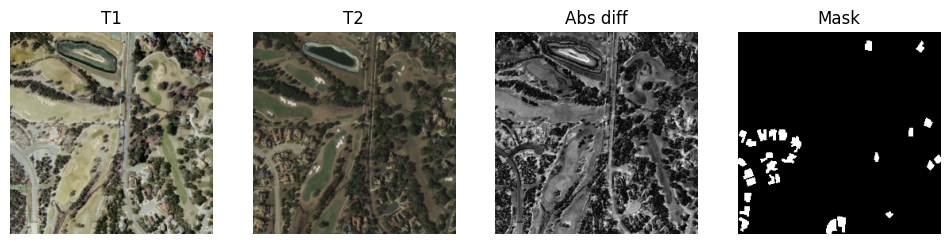

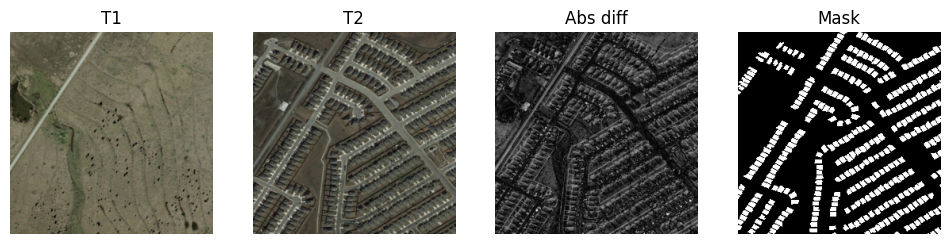

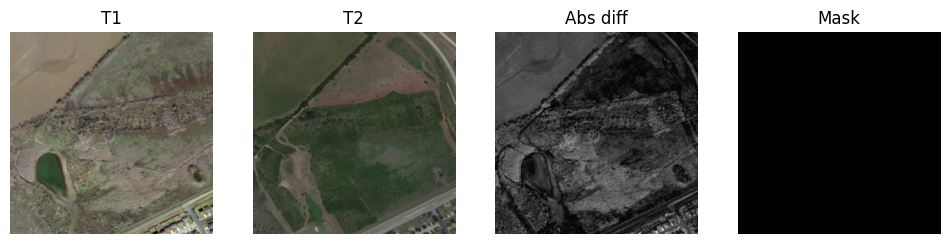

In [5]:
# ============================================================
# 4. Visual sanity check
# ============================================================

def show_batch(dataset=None, n=3):
    dataset=dataset or (selected[0] if selected else None)
    if not dataset:
        print("No selected dataset"); return
    loaders,_=make_loaders(dataset, max_train=16, max_val=8, max_test=8)
    b=next(iter(loaders["train"]))
    for i in range(min(n,b["image_t1"].shape[0])):
        fig,axs=plt.subplots(1,4,figsize=(12,3))
        axs[0].imshow(b["image_t1"][i].permute(1,2,0)); axs[0].set_title("T1")
        axs[1].imshow(b["image_t2"][i].permute(1,2,0)); axs[1].set_title("T2")
        axs[2].imshow(torch.abs(b["image_t2"][i]-b["image_t1"][i]).mean(0), cmap="gray"); axs[2].set_title("Abs diff")
        axs[3].imshow(b["mask"][i,0], cmap="gray"); axs[3].set_title("Mask")
        for ax in axs: ax.axis("off")
        plt.show()

show_batch(selected[0] if selected else None, 3)

In [6]:
# ============================================================
# 5. Models
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(ic,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Conv2d(oc,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Dropout2d(drop) if drop>0 else nn.Identity())
    def forward(self,x): return self.net(x)

class Encoder(nn.Module):
    def __init__(self, base=32, drop=0.05):
        super().__init__(); self.pool=nn.MaxPool2d(2)
        self.c1=ConvBlock(3,base,drop); self.c2=ConvBlock(base,base*2,drop); self.c3=ConvBlock(base*2,base*4,drop); self.c4=ConvBlock(base*4,base*8,drop)
    def forward(self,x):
        f1=self.c1(x); f2=self.c2(self.pool(f1)); f3=self.c3(self.pool(f2)); f4=self.c4(self.pool(f3)); return [f1,f2,f3,f4]

class UpBlock(nn.Module):
    def __init__(self, ic, sc, oc, drop=0.0):
        super().__init__(); self.up=nn.ConvTranspose2d(ic,oc,2,2); self.conv=ConvBlock(oc+sc,oc,drop)
    def forward(self,x,s):
        x=self.up(x)
        if x.shape[-2:]!=s.shape[-2:]: x=F.interpolate(x,size=s.shape[-2:],mode="bilinear",align_corners=False)
        return self.conv(torch.cat([x,s],1))

class SiameseUNet(nn.Module):
    def __init__(self, base=32, drop=0.05):
        super().__init__(); self.enc=Encoder(base,drop)
        self.f1=ConvBlock(base*3,base,drop); self.f2=ConvBlock(base*2*3,base*2,drop); self.f3=ConvBlock(base*4*3,base*4,drop); self.f4=ConvBlock(base*8*3,base*8,drop)
        self.u3=UpBlock(base*8,base*4,base*4,drop); self.u2=UpBlock(base*4,base*2,base*2,drop); self.u1=UpBlock(base*2,base,base,drop); self.head=nn.Conv2d(base,1,1)
    def fuse(self,a,b,layer): return layer(torch.cat([a,b,torch.abs(a-b)],1))
    def forward(self,x1,x2):
        A=self.enc(x1); B=self.enc(x2)
        f1=self.fuse(A[0],B[0],self.f1); f2=self.fuse(A[1],B[1],self.f2); f3=self.fuse(A[2],B[2],self.f3); f4=self.fuse(A[3],B[3],self.f4)
        x=self.u3(f4,f3); x=self.u2(x,f2); x=self.u1(x,f1); return self.head(x)

class LightweightMambaMixer(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.norm=nn.LayerNorm(dim); self.inp=nn.Linear(dim,dim*2); self.dw=nn.Conv1d(dim,dim,5,padding=2,groups=dim); self.gate=nn.Linear(dim,dim); self.out=nn.Linear(dim,dim)
    def forward(self,x):
        z=self.norm(x); a,b=self.inp(z).chunk(2,-1); a=self.dw(a.transpose(1,2)).transpose(1,2); g=torch.sigmoid(self.gate(b)); return x+self.out(torch.tanh(a)*g)

class ObjectTokenBlock(nn.Module):
    def __init__(self, ch, grid=8):
        super().__init__(); self.grid=grid; self.mix=LightweightMambaMixer(ch); self.proj=nn.Sequential(nn.Conv2d(ch*2,ch,1),nn.BatchNorm2d(ch),nn.ReLU(True))
    def forward(self,f):
        B,C,H,W=f.shape; p=F.adaptive_avg_pool2d(f,(self.grid,self.grid)); tok=p.flatten(2).transpose(1,2); tok=self.mix(tok); obj=tok.transpose(1,2).reshape(B,C,self.grid,self.grid); obj=F.interpolate(obj,size=(H,W),mode="bilinear",align_corners=False); return self.proj(torch.cat([f,obj],1))

class ObjChangeMambaDiffLite(nn.Module):
    def __init__(self, base=32, drop=0.10, use_object=True, use_mamba=True):
        super().__init__(); self.use_mamba=use_mamba; self.enc=Encoder(base,drop)
        self.f1=ConvBlock(base*4,base,drop); self.f2=ConvBlock(base*2*4,base*2,drop); self.f3=ConvBlock(base*4*4,base*4,drop); self.f4=ConvBlock(base*8*4,base*8,drop)
        self.o3=ObjectTokenBlock(base*4) if use_object else nn.Identity(); self.o4=ObjectTokenBlock(base*8) if use_object else nn.Identity(); self.m4=LightweightMambaMixer(base*8) if use_mamba else nn.Identity()
        self.u3=UpBlock(base*8,base*4,base*4,drop); self.u2=UpBlock(base*4,base*2,base*2,drop); self.u1=UpBlock(base*2,base,base,drop); self.drop=nn.Dropout2d(drop); self.head=nn.Conv2d(base,1,1)
    def fuse(self,a,b,layer): return layer(torch.cat([a,b,torch.abs(a-b),a*b],1))
    def forward(self,x1,x2):
        A=self.enc(x1); B=self.enc(x2)
        f1=self.fuse(A[0],B[0],self.f1); f2=self.fuse(A[1],B[1],self.f2); f3=self.o3(self.fuse(A[2],B[2],self.f3)); f4=self.o4(self.fuse(A[3],B[3],self.f4))
        if self.use_mamba:
            Bn,C,H,W=f4.shape; tok=f4.flatten(2).transpose(1,2); tok=self.m4(tok); f4=tok.transpose(1,2).reshape(Bn,C,H,W)
        x=self.u3(f4,f3); x=self.u2(x,f2); x=self.u1(x,f1); return self.head(self.drop(x))

def build_model(name):
    if name=="SiameseUNet": return SiameseUNet()
    if name=="ObjChangeMambaDiffLite": return ObjChangeMambaDiffLite(use_object=True,use_mamba=True)
    if name=="ObjChange_noObject": return ObjChangeMambaDiffLite(use_object=False,use_mamba=True)
    if name=="ObjChange_noMamba": return ObjChangeMambaDiffLite(use_object=True,use_mamba=False)
    if name=="ObjChange_noObject_noMamba": return ObjChangeMambaDiffLite(use_object=False,use_mamba=False)
    raise ValueError(name)

with torch.no_grad():
    m=build_model("ObjChangeMambaDiffLite").to(device)
    y=m(torch.randn(1,3,cfg.IMAGE_SIZE,cfg.IMAGE_SIZE,device=device), torch.randn(1,3,cfg.IMAGE_SIZE,cfg.IMAGE_SIZE,device=device))
    print("Model output:", y.shape)
    del m,y
    if torch.cuda.is_available(): torch.cuda.empty_cache()

Model output: torch.Size([1, 1, 256, 256])


In [7]:
# ============================================================
# 6. Loss, metrics, training and evaluation
# ============================================================

class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=1.0, smooth=1.0):
        super().__init__(); self.smooth=smooth; self.register_buffer("pw", torch.tensor([float(pos_weight)]))
    def forward(self, logits, y):
        bce=F.binary_cross_entropy_with_logits(logits,y,pos_weight=self.pw.to(logits.device))
        p=torch.sigmoid(logits); inter=(p*y).sum((1,2,3)); den=p.sum((1,2,3))+y.sum((1,2,3)); dice=1-((2*inter+self.smooth)/(den+self.smooth)).mean()
        return bce+dice

def estimate_pos_weight(loader, max_batches=20):
    pos=0; neg=0
    for i,b in enumerate(loader):
        y=b["mask"]; pos+=float(y.sum()); neg+=float(y.numel()-y.sum())
        if i+1>=max_batches: break
    return 1.0 if pos<=0 else min(neg/pos, cfg.POS_WEIGHT_CLAMP)

def metrics_from_logits(logits,y,thr=0.5):
    probs=torch.sigmoid(logits).detach().cpu().numpy().ravel(); gt=y.detach().cpu().numpy().ravel().astype(np.uint8); pr=(probs>=thr).astype(np.uint8)
    tp=int(((pr==1)&(gt==1)).sum()); fp=int(((pr==1)&(gt==0)).sum()); fn=int(((pr==0)&(gt==1)).sum()); tn=int(((pr==0)&(gt==0)).sum())
    precision=tp/(tp+fp+1e-8); recall=tp/(tp+fn+1e-8); f1=2*precision*recall/(precision+recall+1e-8); iou=tp/(tp+fp+fn+1e-8); acc=(tp+tn)/(tp+tn+fp+fn+1e-8)
    pe=((tp+fp)*(tp+fn)+(fn+tn)*(fp+tn))/((tp+tn+fp+fn+1e-8)**2); kappa=(acc-pe)/(1-pe+1e-8)
    conf=np.maximum(probs,1-probs); correct=(pr==gt).astype(np.float32); ece=0.0
    for lo,hi in zip(np.linspace(0,1,11)[:-1], np.linspace(0,1,11)[1:]):
        m=(conf>=lo)&(conf<hi)
        if m.any(): ece += m.mean()*abs(correct[m].mean()-conf[m].mean())
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1,"iou":iou,"accuracy":acc,"kappa":kappa,"ece":ece}

def aggregate(ms):
    if not ms: return {}
    tp=sum(m["tp"] for m in ms); fp=sum(m["fp"] for m in ms); fn=sum(m["fn"] for m in ms); tn=sum(m["tn"] for m in ms)
    precision=tp/(tp+fp+1e-8); recall=tp/(tp+fn+1e-8); f1=2*precision*recall/(precision+recall+1e-8); iou=tp/(tp+fp+fn+1e-8); acc=(tp+tn)/(tp+tn+fp+fn+1e-8)
    pe=((tp+fp)*(tp+fn)+(fn+tn)*(fp+tn))/((tp+tn+fp+fn+1e-8)**2); kappa=(acc-pe)/(1-pe+1e-8)
    return {"precision":precision,"recall":recall,"f1":f1,"iou":iou,"accuracy":acc,"kappa":kappa,"ece":float(np.mean([m["ece"] for m in ms])),"tp":tp,"fp":fp,"fn":fn,"tn":tn}

def train_one_epoch(model, loader, opt, criterion, scaler):
    model.train(); losses=[]
    for b in tqdm(loader, leave=False, desc="train"):
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device)
        opt.zero_grad(set_to_none=True); use_amp=cfg.AMP and torch.cuda.is_available()
        with autocast(enabled=use_amp): loss=criterion(model(x1,x2),y)
        if use_amp:
            scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); scaler.step(opt); scaler.update()
        else:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval(); losses=[]; ms=[]
    for b in tqdm(loader, leave=False, desc="eval"):
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device)
        logits=model(x1,x2)
        if criterion: losses.append(float(criterion(logits,y).item()))
        ms.append(metrics_from_logits(logits,y,cfg.CHANGE_THRESHOLD))
    out=aggregate(ms); out["loss"]=float(np.mean(losses)) if losses else np.nan
    return out

@torch.no_grad()
def save_qualitative(model, loader, out_dir, max_items=8):
    out_dir=Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True); model.eval(); saved=0
    for b in loader:
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device); prob=torch.sigmoid(model(x1,x2)); pred=(prob>=cfg.CHANGE_THRESHOLD).float()
        for i in range(x1.shape[0]):
            fig,axs=plt.subplots(1,5,figsize=(15,3))
            axs[0].imshow(x1[i].cpu().permute(1,2,0)); axs[0].set_title("T1")
            axs[1].imshow(x2[i].cpu().permute(1,2,0)); axs[1].set_title("T2")
            axs[2].imshow(y[i,0].cpu(),cmap="gray"); axs[2].set_title("GT")
            axs[3].imshow(prob[i,0].cpu(),cmap="magma"); axs[3].set_title("Prob")
            axs[4].imshow(pred[i,0].cpu(),cmap="gray"); axs[4].set_title("Pred")
            for ax in axs: ax.axis("off")
            plt.tight_layout(); fig.savefig(out_dir/f"qual_{saved:03d}.png", dpi=160); plt.close(fig)
            saved+=1
            if saved>=max_items: return saved
    return saved

def train_model_on_dataset(model_name, dataset_name, epochs, experiment_tag="main", max_train=None, max_val=None, max_test=None):
    loaders,_=make_loaders(dataset_name,max_train=max_train,max_val=max_val,max_test=max_test)
    if loaders["train"] is None or loaders["val"] is None:
        print("Skipping missing loaders", dataset_name); return None
    model=build_model(model_name).to(device)
    criterion=DiceBCELoss(estimate_pos_weight(loaders["train"]))
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.LR,weight_decay=cfg.WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=max(1,epochs)); scaler=GradScaler(enabled=cfg.AMP and torch.cuda.is_available())
    best=-1; best_path=OUT_DIR/"checkpoints"/(f"{experiment_tag}_{dataset_name}_{model_name}_best.pt".replace("/","_")); hist=[]; start=time.time()
    for ep in range(1,epochs+1):
        tl=train_one_epoch(model,loaders["train"],opt,criterion,scaler); vm=evaluate(model,loaders["val"],criterion); sch.step()
        hist.append({"experiment":experiment_tag,"dataset":dataset_name,"model":model_name,"epoch":ep,"train_loss":tl,**{f"val_{k}":v for k,v in vm.items() if k not in ["tp","fp","fn","tn"]}})
        print(f"[{experiment_tag}] {dataset_name} {model_name} epoch {ep}/{epochs} train_loss={tl:.4f} val_f1={vm.get('f1',0):.4f} val_iou={vm.get('iou',0):.4f}")
        if vm.get("f1",0)>best:
            best=vm["f1"]; torch.save({"model_state":model.state_dict(),"model_name":model_name,"dataset":dataset_name,"cfg":asdict(cfg),"val_metrics":vm}, best_path)
    if best_path.exists(): model.load_state_dict(torch.load(best_path,map_location=device)["model_state"])
    tm=evaluate(model, loaders["test"] or loaders["val"], criterion)
    save_qualitative(model, loaders["test"] or loaders["val"], OUT_DIR/"qualitative_predictions"/experiment_tag/dataset_name/model_name, cfg.QUALITATIVE_N)
    pd.DataFrame(hist).to_csv(OUT_DIR/"logs"/(f"{experiment_tag}_{dataset_name}_{model_name}_history.csv".replace("/","_")), index=False)
    res={"experiment":experiment_tag,"dataset":dataset_name,"model":model_name,"epochs":epochs,"best_val_f1":best,"test_precision":tm.get("precision"),"test_recall":tm.get("recall"),"test_f1":tm.get("f1"),"test_iou":tm.get("iou"),"test_accuracy":tm.get("accuracy"),"test_kappa":tm.get("kappa"),"test_ece":tm.get("ece"),"test_loss":tm.get("loss"),"checkpoint":str(best_path),"runtime_min":(time.time()-start)/60}
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return res

In [ ]:
# ============================================================
# 7. Main benchmark: baseline vs ObjChange-MambaDiff-Lite
# ============================================================
main_results=[]
if cfg.RUN_MAIN_BENCHMARK:
    for ds in selected:
        for model_name in cfg.MAIN_MODELS:
            res=train_model_on_dataset(model_name, ds, cfg.EPOCHS, "main")
            if res:
                main_results.append(res)
                pd.DataFrame(main_results).to_csv(OUT_DIR/"reports"/"main_benchmark_results.csv", index=False)
main_df=pd.DataFrame(main_results)
if len(main_df): display(main_df.sort_values(["dataset","test_f1"], ascending=[True,False]))

LEVIR-CD train/val/test: 445 64 128


train:   0%|          | 0/112 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

[main] LEVIR-CD SiameseUNet epoch 1/50 train_loss=1.5336 val_f1=0.5281 val_iou=0.3588


train:   0%|          | 0/112 [00:00<?, ?it/s]

...

eval:   0%|          | 0/448 [00:00<?, ?it/s]

[main] DSIFN-CD SiameseUNet epoch 50/50 train_loss=0.6642 val_f1=0.8417 val_iou=0.7267


eval:   0%|          | 0/622 [00:00<?, ?it/s]

DSIFN-CD train/val/test: 11946 1791 2488


train:   0%|          | 0/2987 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 8. Label-efficiency experiments
# ============================================================
label_eff_results=[]
if cfg.RUN_LABEL_EFFICIENCY:
    for ds in selected:
        base_train=get_records(ds,"train")
        if len(base_train)<20:
            print("Skipping label efficiency:", ds); continue
        for frac in cfg.LABEL_FRACTIONS:
            max_train=None if frac>=1 else max(8,int(len(base_train)*frac))
            tag=f"label_eff_{int(frac*100)}pct"
            res=train_model_on_dataset("ObjChangeMambaDiffLite", ds, cfg.LABEL_EFF_EPOCHS, tag, max_train=max_train)
            if res:
                res["label_fraction"]=frac; res["label_samples"]=len(base_train) if max_train is None else max_train
                label_eff_results.append(res)
                pd.DataFrame(label_eff_results).to_csv(OUT_DIR/"reports"/"label_efficiency_results.csv", index=False)
label_df=pd.DataFrame(label_eff_results)
if len(label_df): display(label_df[["dataset","label_fraction","label_samples","test_f1","test_iou","test_kappa","test_ece"]])

In [ ]:
# ============================================================
# 9. Cross-dataset generalisation
# ============================================================

def train_return_model(model_name, dataset_name, epochs):
    loaders,_=make_loaders(dataset_name)
    if loaders["train"] is None or loaders["val"] is None: return None, None
    model=build_model(model_name).to(device); criterion=DiceBCELoss(estimate_pos_weight(loaders["train"]))
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.LR,weight_decay=cfg.WEIGHT_DECAY); scaler=GradScaler(enabled=cfg.AMP and torch.cuda.is_available())
    best=-1; best_state=None
    for ep in range(1,epochs+1):
        tl=train_one_epoch(model,loaders["train"],opt,criterion,scaler); vm=evaluate(model,loaders["val"],criterion)
        print(f"[cross-train] {dataset_name} ep {ep}/{epochs} loss={tl:.4f} val_f1={vm.get('f1',0):.4f}")
        if vm.get("f1",0)>best:
            best=vm["f1"]; best_state={k:v.detach().cpu() for k,v in model.state_dict().items()}
    if best_state: model.load_state_dict(best_state)
    return model, criterion

cross_pairs=[("LEVIR-CD","S2Looking"),("S2Looking","LEVIR-CD"),("DSIFN-CD","CDD"),("SECOND","HRSCD")]
cross_pairs=[p for p in cross_pairs if p[0] in detected_datasets and p[1] in detected_datasets]
cross_results=[]
if cfg.RUN_CROSS_DATASET:
    for tr_ds,te_ds in cross_pairs:
        model,criterion=train_return_model("ObjChangeMambaDiffLite", tr_ds, cfg.CROSS_EPOCHS)
        if model is None: continue
        loaders,_=make_loaders(te_ds); dl=loaders["test"] or loaders["val"]
        if dl:
            m=evaluate(model,dl,criterion)
            row={"experiment":"cross_dataset","train_dataset":tr_ds,"test_dataset":te_ds,"model":"ObjChangeMambaDiffLite",**{f"test_{k}":v for k,v in m.items() if k not in ["tp","fp","fn","tn"]}}
            cross_results.append(row); pd.DataFrame(cross_results).to_csv(OUT_DIR/"reports"/"cross_dataset_results.csv", index=False)
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
cross_df=pd.DataFrame(cross_results)
if len(cross_df): display(cross_df)

In [ ]:
# ============================================================
# 10. Ablation experiments
# ============================================================
ablation_models=["SiameseUNet","ObjChange_noObject_noMamba","ObjChange_noObject","ObjChange_noMamba","ObjChangeMambaDiffLite"]
ablation_dataset="LEVIR-CD" if "LEVIR-CD" in detected_datasets else (selected[0] if selected else None)
ablation_results=[]
if cfg.RUN_ABLATION and ablation_dataset:
    for mn in ablation_models:
        res=train_model_on_dataset(mn, ablation_dataset, max(10,cfg.EPOCHS//2), "ablation")
        if res:
            ablation_results.append(res)
            pd.DataFrame(ablation_results).to_csv(OUT_DIR/"reports"/"ablation_results.csv", index=False)
ablation_df=pd.DataFrame(ablation_results)
if len(ablation_df): display(ablation_df[["dataset","model","test_f1","test_iou","test_kappa","test_ece","runtime_min"]].sort_values("test_f1",ascending=False))

In [ ]:
# ============================================================
# 11. Figures and final summary
# ============================================================

def plot_main_bar(df, metric, fname):
    if df is None or len(df)==0 or metric not in df: return
    plt.figure(figsize=(11,5))
    labels=[f"{r.dataset}\n{r.model}" for r in df.itertuples()]
    plt.bar(range(len(df)), df[metric])
    plt.xticks(range(len(df)), labels, rotation=45, ha="right")
    plt.ylabel(metric); plt.title(metric); plt.tight_layout(); plt.savefig(OUT_DIR/"figures"/fname, dpi=180); plt.show()

if 'main_df' in globals() and len(main_df):
    plot_main_bar(main_df, "test_f1", "main_test_f1.png")
    plot_main_bar(main_df, "test_iou", "main_test_iou.png")
if 'label_df' in globals() and len(label_df):
    for ds,sub in label_df.groupby("dataset"):
        plt.figure(figsize=(7,4)); plt.plot(sub["label_fraction"], sub["test_f1"], marker="o"); plt.grid(True,alpha=0.3)
        plt.xlabel("Label fraction"); plt.ylabel("Test F1"); plt.title(f"Label efficiency: {ds}"); plt.tight_layout(); plt.savefig(OUT_DIR/"figures"/f"label_efficiency_{ds}.png".replace("/","_"), dpi=180); plt.show()

summary={"root":str(ROOT),"output_dir":str(OUT_DIR),"detected_datasets":detected_datasets,"selected_datasets":selected,"total_paired_records":len(all_records),"config":asdict(cfg)}
with open(OUT_DIR/"reports"/"experiment_summary.json","w",encoding="utf-8") as f: json.dump(summary,f,indent=2,default=str)
frames=[]
for name in ["main_df","label_df","cross_df","ablation_df"]:
    if name in globals() and isinstance(globals()[name],pd.DataFrame) and len(globals()[name]): frames.append(globals()[name])
if frames:
    consolidated=pd.concat(frames,ignore_index=True,sort=False)
    consolidated.to_csv(OUT_DIR/"reports"/"ALL_RESULTS_CONSOLIDATED.csv",index=False)
    display(consolidated.head(30))
    print("Saved consolidated results:", OUT_DIR/"reports"/"ALL_RESULTS_CONSOLIDATED.csv")
print(json.dumps(summary,indent=2,default=str))

## Recommended final settings

For a serious manuscript run, use `EPOCHS = 100`, repeat with at least 3 seeds, and report mean ± standard deviation. For limited GPU memory, keep `BATCH_SIZE = 2` or `4` and `IMAGE_SIZE = 256`. The output reports are saved inside:

`D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports`